# CIELAB Banana Ripeness Classification

## 1. Introduction

Banana ripeness moves through four visible stages &mdash; **unripe**, **ripe**, **overripe** and
**rotten** &mdash; and each stage has a characteristic peel colour. This notebook classifies a
banana image into one of those four classes using the **CIELAB** colour space.

CIELAB separates an image's **lightness** (`L*`) from its **chromatic** information
(`a*` = green&harr;red, `b*` = blue&harr;yellow). Ripening is mostly a chromatic change
(green &rarr; yellow &rarr; brown), so working in CIELAB lets the method reason about colour
almost independently of how bright the photo is.

### Problem &rarr; technique &rarr; purpose

| Problem | Technique | Purpose |
|---|---|---|
| Visible image noise | 3&times;3 median filtering | remove isolated speckle while keeping edges sharp |
| Lighting variation | CLAHE on `L*` only | local contrast enhancement without changing colour |
| Background variation | automatic Otsu threshold on the CIELAB `b*` channel + morphology | extract the banana region without a per-image manual threshold |
| Colour similarity between ripeness stages | CIEDE2000 colour-distance features | perceptual colour difference to fixed class reference colours |
| Main colour representation | CIELAB (`L*`, `a*`, `b*`) and its cylindrical form LCh | separate lightness from chromatic information |

The classifier is a **Support Vector Machine** on 23 colour features: `StandardScaler()`
followed by a default `SVC()`. This is the same fixed classification configuration used by
every image-processing approach compared in this project, so differences in the reported
results are attributable to the feature pipeline, not to the classifier.


## 2. Import Libraries

In [1]:
from __future__ import annotations
%matplotlib inline

import time
from dataclasses import dataclass
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.base import clone
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             classification_report, confusion_matrix)

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


## 3. Dataset Preparation

The **Banana Ripeness Classification** dataset (Kaggle) is used with its **original**
train / validation / test split, unchanged.

| Subset | Images |
|---|--:|
| Train | 11,793 |
| Validation | 1,123 |
| Test | 562 |
| **Total** | **13,478** |

All images are processed at **416 &times; 416**.

Set `DATASET_DIR` to your copy of the dataset. `RUN_FROM_RAW_IMAGES` controls whether the
23-feature matrix is **recomputed from the raw images** (Sections 4&ndash;8, ~17 min) or
**loaded from a pre-computed matrix** produced by exactly that code
(`CIELAB_assignment_data/`). The test set is never used for anything except the single
final evaluation in Section 11.

In [2]:
DATASET_DIR = Path(r"C:\Users\tanxi\Desktop\Y2S3\IP\Banana Ripeness Classification Dataset")
DATA_DIR    = Path("CIELAB_assignment_data")     # pre-computed feature matrices
RUN_FROM_RAW_IMAGES = False                      # True -> recompute features from the images

CLASS_ORDER    = ["unripe", "ripe", "overripe", "rotten"]
SUBSETS        = ["train", "valid", "test"]
EXPECTED_COUNTS = {"train": 11793, "valid": 1123, "test": 562}
IMAGE_SUFFIXES = {".jpg", ".jpeg", ".png", ".bmp"}
EXPECTED_SIZE  = (416, 416)                       # (width, height) for cv2.resize

@dataclass(frozen=True)
class ImageRecord:
    path: Path
    subset: str
    class_name: str

def discover_records(root: Path) -> list[ImageRecord]:
    records = []
    for subset in SUBSETS:
        for class_name in CLASS_ORDER:
            folder = root / subset / class_name
            if not folder.is_dir():
                raise FileNotFoundError(f"Missing folder: {folder}")
            for p in sorted(folder.iterdir()):
                if p.suffix.lower() in IMAGE_SUFFIXES:
                    records.append(ImageRecord(p, subset, class_name))
    return records

DATASET_AVAILABLE = DATASET_DIR.is_dir()
if DATASET_AVAILABLE:
    records = discover_records(DATASET_DIR)
    counts = pd.Series([r.subset for r in records]).value_counts()
    dist = (pd.DataFrame([(r.subset, r.class_name) for r in records],
                         columns=["subset", "class"])
              .pivot_table(index="class", columns="subset", aggfunc=len, fill_value=0)
              .reindex(index=CLASS_ORDER, columns=SUBSETS))
    print("Images per subset:", counts.to_dict())
    assert counts.to_dict() == EXPECTED_COUNTS, "subset counts differ from the published dataset"
    display(dist)
else:
    records = []
    print(f"Dataset folder not found at {DATASET_DIR}")
    print("-> Sections 4-8 demos are skipped; the feature matrix is loaded from", DATA_DIR)

Images per subset: {'train': 11793, 'valid': 1123, 'test': 562}


subset,train,valid,test
class,,,
unripe,1902,167,110
ripe,3522,339,154
overripe,2349,229,113
rotten,4020,388,185


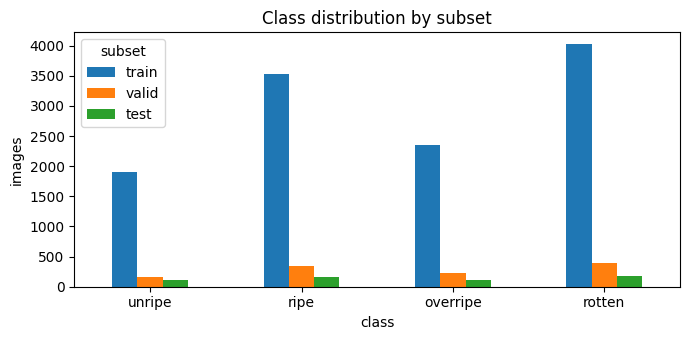

In [3]:
if DATASET_AVAILABLE:
    ax = dist.plot(kind="bar", figsize=(7, 3.5), rot=0)
    ax.set_ylabel("images"); ax.set_title("Class distribution by subset")
    plt.tight_layout(); plt.show()

## 4. Image Preprocessing

Each image is read, resized to 416&times;416, and **median filtered with a 3&times;3 kernel**.
Median filtering removes isolated speckle / compression noise while preserving edges &mdash;
important so that the later segmentation threshold and the colour statistics are not distorted
by noise.

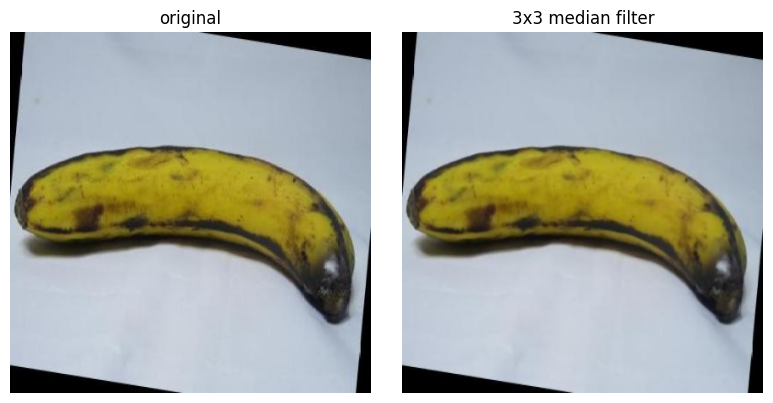

In [4]:
MEDIAN_KERNEL = 3

def load_rgb(path) -> np.ndarray:
    data = np.fromfile(str(path), dtype=np.uint8)
    bgr = cv2.imdecode(data, cv2.IMREAD_COLOR)
    if bgr is None:
        raise ValueError(f"Could not read image: {path}")
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    if rgb.shape[:2] != (EXPECTED_SIZE[1], EXPECTED_SIZE[0]):
        rgb = cv2.resize(rgb, EXPECTED_SIZE, interpolation=cv2.INTER_AREA)
    return rgb

def median_filter(rgb: np.ndarray) -> np.ndarray:
    return cv2.medianBlur(rgb, MEDIAN_KERNEL)

if DATASET_AVAILABLE:
    sample = load_rgb(next(r.path for r in records if r.subset == "train" and r.class_name == "overripe"))
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(sample);                ax[0].set_title("original");        ax[0].axis("off")
    ax[1].imshow(median_filter(sample)); ax[1].set_title("3x3 median filter"); ax[1].axis("off")
    plt.tight_layout(); plt.show()

## 5. CIELAB Colour Conversion

The denoised image is converted from RGB to CIELAB. OpenCV stores 8-bit Lab, so the channels
are rescaled to true colorimetric units (`L* in [0,100]`, `a*, b* in [-128,127]`), which the
CIEDE2000 metric in Section 8 requires.

* `L*` &mdash; lightness
* `a*` &mdash; green (&minus;) &harr; red (+)
* `b*` &mdash; blue (&minus;) &harr; yellow (+)

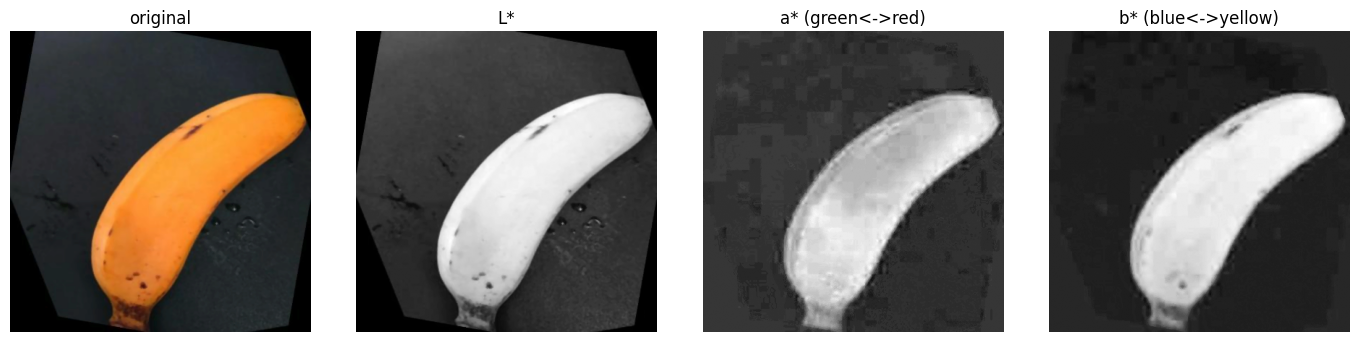

In [5]:
def to_true_lab_units(L8, a8, b8):
    return (L8.astype(np.float64) * (100.0 / 255.0),
            a8.astype(np.float64) - 128.0,
            b8.astype(np.float64) - 128.0)

if DATASET_AVAILABLE:
    lab8 = cv2.cvtColor(median_filter(load_rgb(
        next(r.path for r in records if r.subset == "train" and r.class_name == "ripe"))),
        cv2.COLOR_RGB2LAB)
    L8, a8, b8 = cv2.split(lab8)
    L, a, b = to_true_lab_units(L8, a8, b8)
    fig, ax = plt.subplots(1, 4, figsize=(14, 3.4))
    for axi, (name, ch) in zip(ax, [("original", None), ("L*", L),
                                    ("a* (green<->red)", a), ("b* (blue<->yellow)", b)]):
        axi.imshow(cv2.cvtColor(lab8, cv2.COLOR_LAB2RGB) if ch is None else ch,
                   cmap=None if ch is None else "gray")
        axi.set_title(name); axi.axis("off")
    plt.tight_layout(); plt.show()

## 6. CLAHE Enhancement

**Contrast-Limited Adaptive Histogram Equalisation** is applied to the **`L*` channel only**
(clip limit 2.0, 8&times;8 tiles). It boosts local contrast so the banana separates cleanly from
the background under uneven lighting, while leaving `a*` and `b*` &mdash; the colour the
classifier actually uses &mdash; unchanged.

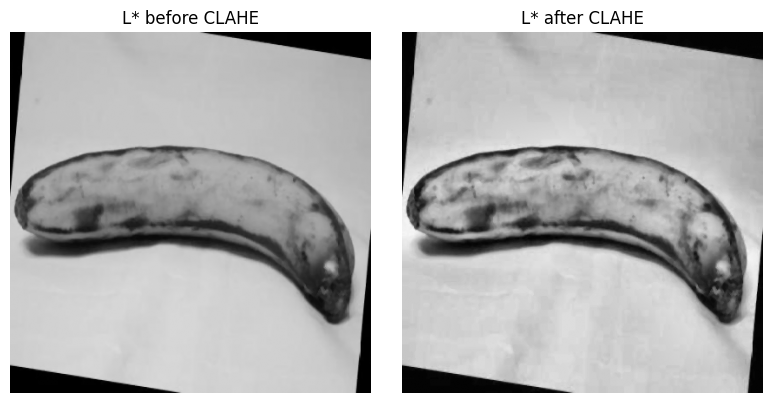

In [6]:
CLAHE_CLIP_LIMIT = 2.0
CLAHE_TILE_GRID  = (8, 8)

def prepare_cielab_channels(rgb: np.ndarray) -> dict:
    '''Median filter -> RGB->CIELAB -> CLAHE on the 8-bit L channel.'''
    denoised = cv2.medianBlur(rgb, MEDIAN_KERNEL)
    lab = cv2.cvtColor(denoised, cv2.COLOR_RGB2LAB)
    L8, a8, b8 = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=CLAHE_CLIP_LIMIT, tileGridSize=CLAHE_TILE_GRID)
    return {"L8_raw": L8, "L8": clahe.apply(L8), "a8": a8, "b8": b8}

if DATASET_AVAILABLE:
    ch = prepare_cielab_channels(load_rgb(
        next(r.path for r in records if r.subset == "train" and r.class_name == "overripe")))
    fig, ax = plt.subplots(1, 2, figsize=(8, 4))
    ax[0].imshow(ch["L8_raw"], cmap="gray", vmin=0, vmax=255); ax[0].set_title("L* before CLAHE"); ax[0].axis("off")
    ax[1].imshow(ch["L8"],     cmap="gray", vmin=0, vmax=255); ax[1].set_title("L* after CLAHE");  ax[1].axis("off")
    plt.tight_layout(); plt.show()

## 7. Banana Region Segmentation

The banana is isolated using an **automatic Otsu threshold on the `b*` channel**. Bananas are
strongly positive on `b*` (yellow) at every ripeness stage, while typical backgrounds are close
to neutral, so `b*` gives a clean separation and Otsu chooses the threshold automatically (no
per-image tuning).

The raw mask is then refined by **morphology**: opening then closing with a 5&times;5 elliptical
element, keeping the **largest connected component** (the banana), and filling only **small**
enclosed holes (a large enclosed dark region is a genuine rotten patch and is kept).

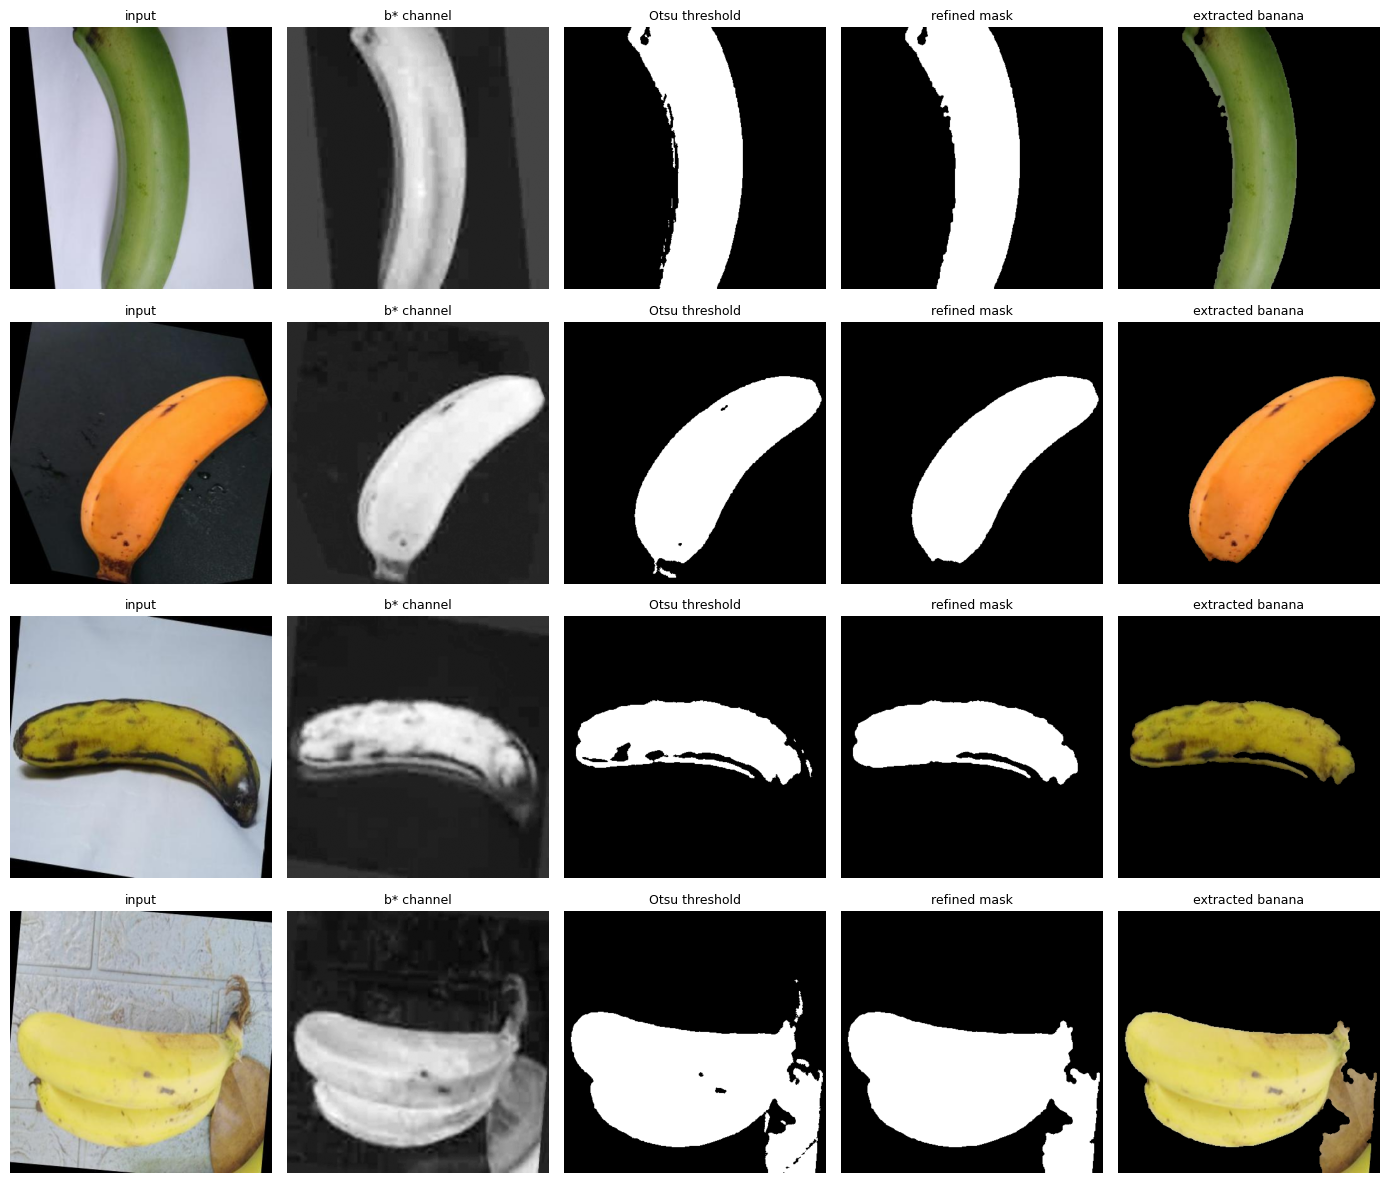

In [7]:
MORPH_KERNEL_SIZE = 5
CONNECTIVITY = 8
HOLE_MAX_COMPONENT_FRACTION = 0.25
HOLE_MAX_IMAGE_FRACTION     = 0.05
MIN_FOREGROUND_FRACTION, MAX_FOREGROUND_FRACTION = 0.02, 0.90

@dataclass(frozen=True)
class SegmentationResult:
    b_mask: np.ndarray
    final_mask: np.ndarray
    b_otsu_threshold: float
    foreground_fraction: float
    suspicious_mask: bool

def _fill_small_holes(mask: np.ndarray) -> np.ndarray:
    inverted = np.where(mask > 0, 0, 255).astype(np.uint8)
    count, labels, stats, _ = cv2.connectedComponentsWithStats(inverted, connectivity=4)
    image_area, banana_area = float(mask.size), float(np.count_nonzero(mask))
    filled = mask.copy()
    border = set(labels[0, :]) | set(labels[-1, :]) | set(labels[:, 0]) | set(labels[:, -1])
    for lab in range(1, count):
        if lab in border:
            continue
        area = float(stats[lab, cv2.CC_STAT_AREA])
        if banana_area > 0 and area > HOLE_MAX_COMPONENT_FRACTION * banana_area:
            continue
        if area > HOLE_MAX_IMAGE_FRACTION * image_area:
            continue
        filled[labels == lab] = 255
    return filled

def segment_banana(b8: np.ndarray) -> SegmentationResult:
    threshold, mask = cv2.threshold(b8, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    b_mask = mask.copy()
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (MORPH_KERNEL_SIZE, MORPH_KERNEL_SIZE))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  kernel, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=1)
    count, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=CONNECTIVITY)
    if count > 1:
        largest = 1 + int(np.argmax(stats[1:, cv2.CC_STAT_AREA]))
        mask = np.where(labels == largest, 255, 0).astype(np.uint8)
    mask = _fill_small_holes(mask)
    frac = float(np.count_nonzero(mask)) / float(mask.size)
    return SegmentationResult(b_mask, mask, float(threshold), frac,
                              not (MIN_FOREGROUND_FRACTION <= frac <= MAX_FOREGROUND_FRACTION))

if DATASET_AVAILABLE:
    fig, ax = plt.subplots(len(CLASS_ORDER), 5, figsize=(14, 12))
    for r, c in enumerate(CLASS_ORDER):
        rgb = load_rgb(next(rec.path for rec in records if rec.subset == "train" and rec.class_name == c))
        ch = prepare_cielab_channels(rgb); seg = segment_banana(ch["b8"])
        panels = [(rgb, "input", None), (ch["b8"], "b* channel", "gray"),
                  (seg.b_mask, "Otsu threshold", "gray"), (seg.final_mask, "refined mask", "gray"),
                  (np.where(seg.final_mask[..., None] > 0, rgb, 0), "extracted banana", None)]
        for axi, (im, t, cm) in zip(ax[r], panels):
            axi.imshow(im, cmap=cm); axi.set_title(t, fontsize=9); axi.axis("off")
        ax[r, 0].set_ylabel(c, fontsize=11)
    plt.tight_layout(); plt.show()

## 8. Feature Extraction

**23 colour features** are extracted over the segmented banana pixels only.

**CIELAB statistical features (15)** &mdash; for each of `L*`, `a*`, `b*`: mean, median,
standard deviation, 10th percentile, 90th percentile.

**Foreground feature (1)** &mdash; `foreground_fraction` = banana area &divide; image area.

**CIEDE2000 features (4)** &mdash; perceptual colour distance (&Delta;E00) from the banana's
median colour to four fixed **class reference colours** ("prototypes"). Each prototype is the
median of the per-image median colours of that class, **computed from the training set only**.

**Additional CIELAB / LCh features (3)**
* `dark_region_mean_L` &mdash; mean `L*` of the banana's dark pixels (`L* < 40`); a conditional
  CIELAB lightness statistic.
* `h_std` &mdash; standard deviation of the **hue angle** `h_ab = atan2(b*, a*)`, i.e. the
  cylindrical (LCh) form of the same `a*`/`b*` plane. A banana with mixed green and yellow
  regions has a wide hue spread.
* `dE_margin_mean` &mdash; mean per-pixel gap between the **nearest** and **second-nearest**
  prototype &Delta;E00. A small gap means the pixel colour is perceptually between two stages.

In [8]:
LAB_STAT_FEATURES  = [f"{c}_{s}" for c in ("L", "a", "b")
                      for s in ("mean", "median", "std", "p10", "p90")] + ["foreground_fraction"]
CIEDE2000_FEATURES = [f"ciede2000_to_{c}" for c in CLASS_ORDER]
EXTRA_FEATURES     = ["dark_region_mean_L", "h_std", "dE_margin_mean"]
FEATURE_NAMES      = LAB_STAT_FEATURES + CIEDE2000_FEATURES + EXTRA_FEATURES
assert len(FEATURE_NAMES) == 23
DARK_L = 40.0

def ciede2000(lab1, lab2):
    '''CIEDE2000 colour difference between CIELAB colours in true units (vectorised).'''
    lab1, lab2 = np.asarray(lab1, np.float64), np.asarray(lab2, np.float64)
    L1, a1, b1 = lab1[..., 0], lab1[..., 1], lab1[..., 2]
    L2, a2, b2 = lab2[..., 0], lab2[..., 1], lab2[..., 2]
    C1, C2 = np.hypot(a1, b1), np.hypot(a2, b2)
    C_bar7 = (0.5 * (C1 + C2)) ** 7
    G = 0.5 * (1.0 - np.sqrt(C_bar7 / (C_bar7 + 25.0 ** 7)))
    a1p, a2p = (1.0 + G) * a1, (1.0 + G) * a2
    C1p, C2p = np.hypot(a1p, b1), np.hypot(a2p, b2)
    h1p = np.where((np.abs(a1p) + np.abs(b1)) == 0.0, 0.0, np.degrees(np.arctan2(b1, a1p)) % 360.0)
    h2p = np.where((np.abs(a2p) + np.abs(b2)) == 0.0, 0.0, np.degrees(np.arctan2(b2, a2p)) % 360.0)
    dLp, dCp = L2 - L1, C2p - C1p
    dhp = h2p - h1p
    dhp = np.where(dhp > 180.0, dhp - 360.0, dhp)
    dhp = np.where(dhp < -180.0, dhp + 360.0, dhp)
    dhp = np.where(C1p * C2p == 0.0, 0.0, dhp)
    dHp = 2.0 * np.sqrt(C1p * C2p) * np.sin(np.radians(0.5 * dhp))
    Lp_bar, Cp_bar = 0.5 * (L1 + L2), 0.5 * (C1p + C2p)
    h_sum, h_diff = h1p + h2p, np.abs(h1p - h2p)
    hp_bar = np.where(h_diff <= 180.0, 0.5 * h_sum,
             np.where(h_sum < 360.0, 0.5 * (h_sum + 360.0), 0.5 * (h_sum - 360.0)))
    hp_bar = np.where(C1p * C2p == 0.0, h_sum, hp_bar)
    T = (1.0 - 0.17 * np.cos(np.radians(hp_bar - 30.0)) + 0.24 * np.cos(np.radians(2.0 * hp_bar))
             + 0.32 * np.cos(np.radians(3.0 * hp_bar + 6.0)) - 0.20 * np.cos(np.radians(4.0 * hp_bar - 63.0)))
    Cp_bar7 = Cp_bar ** 7
    R_C = 2.0 * np.sqrt(Cp_bar7 / (Cp_bar7 + 25.0 ** 7))
    R_T = -R_C * np.sin(np.radians(2.0 * (30.0 * np.exp(-(((hp_bar - 275.0) / 25.0) ** 2)))))
    S_L = 1.0 + (0.015 * (Lp_bar - 50.0) ** 2) / np.sqrt(20.0 + (Lp_bar - 50.0) ** 2)
    S_C = 1.0 + 0.045 * Cp_bar
    S_H = 1.0 + 0.015 * Cp_bar * T
    tL, tC, tH = dLp / S_L, dCp / S_C, dHp / S_H
    return np.sqrt(tL ** 2 + tC ** 2 + tH ** 2 + R_T * tC * tH)

def build_prototypes(train_features: pd.DataFrame) -> pd.DataFrame:
    '''Four class reference colours - TRAINING subset only.'''
    assert train_features["subset"].eq("train").all(), "prototypes must use training data only"
    rows = []
    for c in CLASS_ORDER:
        cr = train_features[train_features["ground_truth_class"] == c]
        rows.append({"class_name": c,
                     "prototype_L": float(cr["L_median"].median()),
                     "prototype_a": float(cr["a_median"].median()),
                     "prototype_b": float(cr["b_median"].median())})
    return pd.DataFrame(rows)

def lab_statistics(L, a, b, mask) -> dict | None:
    sel = mask > 0
    if not sel.any():
        return None
    row = {}
    for name, ch in (("L", L), ("a", a), ("b", b)):
        v = ch[sel]
        row[f"{name}_mean"]   = float(v.mean())
        row[f"{name}_median"] = float(np.median(v))
        row[f"{name}_std"]    = float(v.std())
        row[f"{name}_p10"]    = float(np.percentile(v, 10))
        row[f"{name}_p90"]    = float(np.percentile(v, 90))
    row["foreground_fraction"] = float(sel.sum()) / float(mask.size)
    return row

def ciede2000_and_extra_features(L, a, b, mask, prototypes) -> dict:
    sel = mask > 0
    med = np.array([np.median(L[sel]), np.median(a[sel]), np.median(b[sel])], np.float64)
    proto = {r.class_name: np.array([r.prototype_L, r.prototype_a, r.prototype_b], np.float64)
             for r in prototypes.itertuples()}
    out = {f"ciede2000_to_{c}": float(ciede2000(med, proto[c])) for c in CLASS_ORDER}
    px = np.stack([L[sel], a[sel], b[sel]], axis=1).astype(np.float64)
    dE = np.stack([ciede2000(px, np.broadcast_to(proto[c], px.shape)) for c in CLASS_ORDER], axis=1)
    sd = np.sort(dE, axis=1)
    hue = np.degrees(np.arctan2(b[sel], a[sel])) % 360.0
    dark = L[sel] < DARK_L
    out["dark_region_mean_L"] = float(L[sel][dark].mean()) if dark.any() else DARK_L
    out["h_std"] = float(hue.std())
    out["dE_margin_mean"] = float((sd[:, 1] - sd[:, 0]).mean())
    return out

def extract_all_features(rgb: np.ndarray, prototypes: pd.DataFrame):
    '''The full 23-feature vector for one image -> (dict, SegmentationResult, (L,a,b)).'''
    ch = prepare_cielab_channels(rgb)
    seg = segment_banana(ch["b8"])
    L, a, b = to_true_lab_units(ch["L8"], ch["a8"], ch["b8"])
    stats = lab_statistics(L, a, b, seg.final_mask)
    if stats is None:
        return None, seg, None
    stats.update(ciede2000_and_extra_features(L, a, b, seg.final_mask, prototypes))
    return {k: stats[k] for k in FEATURE_NAMES}, seg, (L, a, b)

# quick correctness check of the CIEDE2000 implementation (Sharma, Wu & Dalal 2005, Table 1)
_cases = [((50, 2.6772, -79.7751), (50, 0, -82.7485), 2.0425),
          ((50, 2.5, 0.0), (73, 25, -18), 27.1492)]
print("CIEDE2000 self-check (max error vs published values):",
      f"{max(abs(float(ciede2000(np.array(p), np.array(q))) - e) for p, q, e in _cases):.1e}")

CIEDE2000 self-check (max error vs published values): 4.0e-05


## 9. Feature Preparation

The **class reference colours (prototypes)** are built from the **training set only**, and the
`StandardScaler` inside the classification pipeline is likewise fitted on training data only.
The validation set is used to confirm the finalised configuration; the test set is untouched
until Section 11.

The feature matrix below is either recomputed from the raw images (`RUN_FROM_RAW_IMAGES = True`)
or loaded from a pre-computed file produced by the code in Sections 4&ndash;8.

In [9]:
def process_all_images(records, prototypes=None):
    '''Return a DataFrame of the 23 features for every record.
    Two passes: pass 1 = Lab statistics (needed to build prototypes); pass 2 = CIEDE2000 + extras.'''
    base = []
    t0 = time.time()
    for i, rec in enumerate(records, 1):
        ch = prepare_cielab_channels(load_rgb(rec.path))
        seg = segment_banana(ch["b8"])
        L, a, b = to_true_lab_units(ch["L8"], ch["a8"], ch["b8"])
        s = lab_statistics(L, a, b, seg.final_mask)
        s.update(image_path=str(rec.path), subset=rec.subset, ground_truth_class=rec.class_name)
        base.append(s)
        if i % 2000 == 0:
            print(f"  pass 1: {i}/{len(records)}  ({time.time()-t0:.0f}s)")
    base = pd.DataFrame(base)
    if prototypes is None:
        prototypes = build_prototypes(base[base.subset == "train"])
    rows = []
    for i, rec in enumerate(records, 1):
        ch = prepare_cielab_channels(load_rgb(rec.path))
        seg = segment_banana(ch["b8"])
        L, a, b = to_true_lab_units(ch["L8"], ch["a8"], ch["b8"])
        rows.append(ciede2000_and_extra_features(L, a, b, seg.final_mask, prototypes))
        if i % 2000 == 0:
            print(f"  pass 2: {i}/{len(records)}")
    full = pd.concat([base.reset_index(drop=True), pd.DataFrame(rows)], axis=1)
    return full, prototypes

if RUN_FROM_RAW_IMAGES and DATASET_AVAILABLE:
    print("Recomputing the 23-feature matrix from the raw images (~17 min) ...")
    full, prototypes = process_all_images(records)
    feat_tv = full[full.subset.isin(["train", "valid"])].reset_index(drop=True)
    feat_te = full[full.subset == "test"].reset_index(drop=True)
    train_valid = feat_tv[["ground_truth_class"] + FEATURE_NAMES]
    test_df     = feat_te[["ground_truth_class"] + FEATURE_NAMES]
    source_note = "recomputed from raw images by this notebook"
else:
    train_valid = pd.read_csv(DATA_DIR / "train_valid_features.csv.gz")
    test_df     = pd.read_csv(DATA_DIR / "test_features.csv.gz")
    prototypes  = pd.read_csv(DATA_DIR / "training_prototypes.csv")
    source_note = "loaded from a pre-computed matrix produced by the code in Sections 4-8"

N_VALID = 1123   # train_valid is train (11,793) followed by valid (1,123)
assert list(train_valid.columns) == ["ground_truth_class"] + FEATURE_NAMES
assert len(train_valid) == 12916 and len(test_df) == 562
print("Feature matrix:", source_note)
print("  train + valid:", train_valid.shape, "  test:", test_df.shape, "  features:", len(FEATURE_NAMES))
print("\nClass reference colours (CIEDE2000 prototypes, training set only):")
display(prototypes.round(2))

Feature matrix: loaded from a pre-computed matrix produced by the code in Sections 4-8
  train + valid: (12916, 24)   test: (562, 24)   features: 23

Class reference colours (CIEDE2000 prototypes, training set only):


,class_name,prototype_L,prototype_a,prototype_b,training_images,prototype_source_subset
0,unripe,50.98,-18.0,38.0,1902,train
1,ripe,65.10,-6.0,54.0,3522,train
2,overripe,52.16,0.0,31.0,2349,train
3,rotten,59.61,1.0,43.0,4020,train


In [10]:
# a compact view of the 23 features (per-class means) instead of the full dataframe
display(train_valid.groupby("ground_truth_class")[FEATURE_NAMES].mean().round(2).T
        .reindex(columns=CLASS_ORDER))

# verification: the pre-computed matrix equals what this notebook's code produces
if DATASET_AVAILABLE and not RUN_FROM_RAW_IMAGES:
    diffs = []
    for c in CLASS_ORDER:
        p = next(r.path for r in records if r.subset == "test" and r.class_name == c)
        feats, _, _ = extract_all_features(load_rgb(p), prototypes)
        v = np.array([feats[k] for k in FEATURE_NAMES])
        cand = test_df[test_df.ground_truth_class == c][FEATURE_NAMES].to_numpy(np.float64)
        diffs.append(float(np.abs(cand - v).sum(axis=1).min()))
    print(f"pre-computed vs freshly extracted (4 test images): max abs difference = {max(diffs):.1e}")

ground_truth_class,unripe,ripe,overripe,rotten
L_mean,51.88,63.73,50.98,58.42
L_median,52.31,66.40,52.06,60.41
L_std,13.42,13.79,15.33,16.75
L_p10,33.85,44.65,29.66,34.79
L_p90,69.33,78.60,70.43,78.72
a_mean,-17.66,-3.81,0.25,0.25
a_median,-18.33,-4.11,0.16,-0.30
a_std,3.91,4.13,3.70,6.39
a_p10,-21.93,-8.46,-4.49,-7.45
a_p90,-12.41,1.06,5.12,8.76


pre-computed vs freshly extracted (4 test images): max abs difference = 1.2e-14


## 10. Classification Model

The classifier is `StandardScaler()` &rarr; `SVC()` (RBF kernel, scikit-learn defaults,
`probability=False`), fitted on the 23 CIELAB / LCh / CIEDE2000 features from Section 8.

This is the classification configuration agreed across the whole group: no hyperparameter is
tuned, and it is identical for every image-processing approach compared in this project (HSV,
CIELAB, RGB, YCbCr, K-means). No approach applies any additional classification-stage
adjustment on top of it, so any difference in the reported results is attributable to the
image-processing pipeline that produced the input features, not to the classifier.


In [11]:
model = Pipeline([
    ("scaler", StandardScaler()),
    ("svm", SVC(random_state=RANDOM_SEED)),
])
model


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('svm', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'


## 11. Model Evaluation

Three stages are reported, matching the two-stage protocol used throughout this project. Each
stage is shown as a metrics table, a confusion-matrix table, and a confusion-matrix image, so
the same result can be read either way in documentation.

**Training** &mdash; the model fitted on the training set only, evaluated back on that same
training set. This shows how well the model fits the data it was trained on.

**Validation** &mdash; the same training-set model, evaluated on the held-out validation set, to
confirm the finalised configuration before touching the test set.

**Train + validation and official test** &mdash; the finalised model is refitted once on
**train + validation (12,916 images)**, its fit is checked on that same combined set, and it is
then evaluated **once** on the untouched **562-image test set**.


Model fitted on the training set only:


,Accuracy,Macro precision,Macro recall,Macro F1
Stage,,,,
Training,0.9473,0.9503,0.9504,0.9502
Validation,0.9581,0.9589,0.9624,0.9605



Training confusion matrix (table):


,pred unripe,pred ripe,pred overripe,pred rotten
true unripe,1875,3,1,23
true ripe,5,3359,32,126
true overripe,2,155,2176,16
true rotten,38,127,94,3761


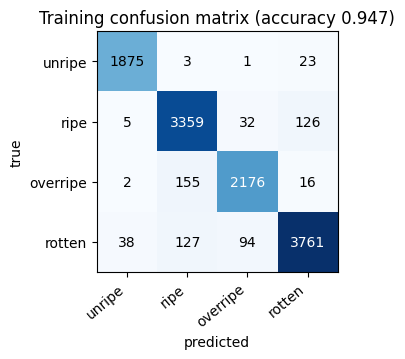


Validation confusion matrix (table):


,pred unripe,pred ripe,pred overripe,pred rotten
true unripe,166,0,0,1
true ripe,0,327,3,9
true overripe,0,12,217,0
true rotten,6,10,6,366


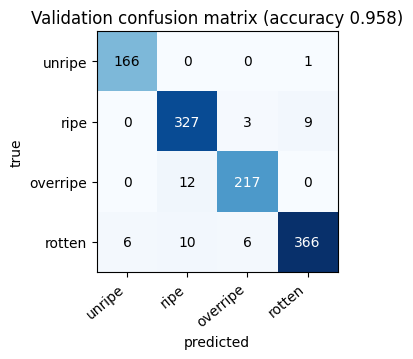

In [12]:
def scores(y_true, y_pred):
    p, r, f1, sup = precision_recall_fscore_support(y_true, y_pred, labels=CLASS_ORDER, zero_division=0)
    mp, mr, mf, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    return mp, mr, mf, (p, r, f1, sup)

def confusion_table(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
    return pd.DataFrame(cm, index=[f"true {c}" for c in CLASS_ORDER],
                         columns=[f"pred {c}" for c in CLASS_ORDER])

def plot_confusion(y_true, y_pred, title):
    cm = confusion_matrix(y_true, y_pred, labels=CLASS_ORDER)
    fig, ax = plt.subplots(figsize=(4.2, 3.7))
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(4), CLASS_ORDER, rotation=40, ha="right"); ax.set_yticks(range(4), CLASS_ORDER)
    for i in range(4):
        for j in range(4):
            ax.text(j, i, cm[i, j], ha="center", va="center",
                    color="white" if cm[i, j] > cm.max() * 0.5 else "black")
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    plt.tight_layout(); plt.show()

Xtr = train_valid.iloc[:-N_VALID][FEATURE_NAMES].to_numpy(np.float64)
ytr = train_valid.iloc[:-N_VALID]["ground_truth_class"].to_numpy(str)
Xva = train_valid.iloc[-N_VALID:][FEATURE_NAMES].to_numpy(np.float64)
yva = train_valid.iloc[-N_VALID:]["ground_truth_class"].to_numpy(str)

val_model = clone(model).fit(Xtr, ytr)
train_pred = val_model.predict(Xtr)
valid_pred = val_model.predict(Xva)

rows = []
for name, y_true, y_pred in [("Training", ytr, train_pred), ("Validation", yva, valid_pred)]:
    mp_, mr_, mf_, _ = scores(y_true, y_pred)
    rows.append({"Stage": name, "Accuracy": accuracy_score(y_true, y_pred),
                 "Macro precision": mp_, "Macro recall": mr_, "Macro F1": mf_})
metrics_stage1 = pd.DataFrame(rows).set_index("Stage").round(4)
print("Model fitted on the training set only:")
display(metrics_stage1)

print("\nTraining confusion matrix (table):")
display(confusion_table(ytr, train_pred))
plot_confusion(ytr, train_pred, f"Training confusion matrix (accuracy {accuracy_score(ytr, train_pred):.3f})")

print("\nValidation confusion matrix (table):")
display(confusion_table(yva, valid_pred))
plot_confusion(yva, valid_pred, f"Validation confusion matrix (accuracy {accuracy_score(yva, valid_pred):.3f})")


Final model fitted on train + validation (12,916 images):


,Accuracy,Macro precision,Macro recall,Macro F1,Weighted F1
Stage,,,,,
Train + Validation,0.9507,0.9533,0.9536,0.9532,0.9507
Official Test,0.9484,0.9495,0.9491,0.9490,0.9484



Train + Validation confusion matrix (table):


,pred unripe,pred ripe,pred overripe,pred rotten
true unripe,2039,3,1,26
true ripe,4,3718,34,105
true overripe,2,162,2399,15
true rotten,43,144,98,4123


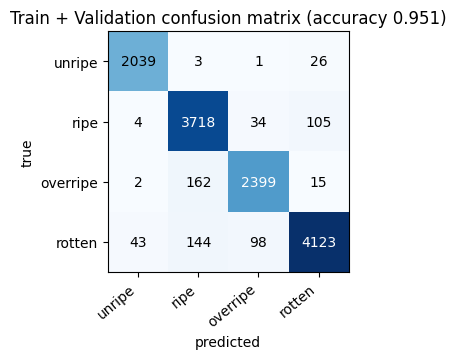


Official test confusion matrix (table):


,pred unripe,pred ripe,pred overripe,pred rotten
true unripe,105,1,0,4
true ripe,0,150,1,3
true overripe,0,7,106,0
true rotten,2,4,7,172


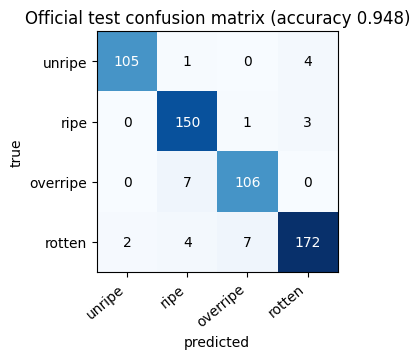

In [13]:
# --- final model: fit on train + validation, evaluate once on the official test set ---
X_fit = train_valid[FEATURE_NAMES].to_numpy(np.float64)
y_fit = train_valid["ground_truth_class"].to_numpy(str)
X_test = test_df[FEATURE_NAMES].to_numpy(np.float64)
y_test = test_df["ground_truth_class"].to_numpy(str)

final_model = clone(model).fit(X_fit, y_fit)
fit_pred = final_model.predict(X_fit)
test_pred = final_model.predict(X_test)

rows = []
for name, y_true, y_pred in [("Train + Validation", y_fit, fit_pred), ("Official Test", y_test, test_pred)]:
    mp_, mr_, mf_, _ = scores(y_true, y_pred)
    _, _, wf_, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    rows.append({"Stage": name, "Accuracy": accuracy_score(y_true, y_pred),
                 "Macro precision": mp_, "Macro recall": mr_, "Macro F1": mf_, "Weighted F1": wf_})
metrics_stage2 = pd.DataFrame(rows).set_index("Stage").round(4)
print("Final model fitted on train + validation (12,916 images):")
display(metrics_stage2)

print("\nTrain + Validation confusion matrix (table):")
display(confusion_table(y_fit, fit_pred))
plot_confusion(y_fit, fit_pred, f"Train + Validation confusion matrix (accuracy {accuracy_score(y_fit, fit_pred):.3f})")

print("\nOfficial test confusion matrix (table):")
display(confusion_table(y_test, test_pred))
plot_confusion(y_test, test_pred, f"Official test confusion matrix (accuracy {accuracy_score(y_test, test_pred):.3f})")

# reused below for the per-class table
acc = accuracy_score(y_test, test_pred)
mp, mr, mf, (p, r, f1, sup) = scores(y_test, test_pred)
_, _, wf, _ = precision_recall_fscore_support(y_test, test_pred, average="weighted", zero_division=0)


In [14]:
per_class = pd.DataFrame({"Precision": p, "Recall": r, "F1-score": f1, "Support": sup},
                          index=CLASS_ORDER).round(4)
print("Official test - per-class results:")
display(per_class)


Official test - per-class results:


,Precision,Recall,F1-score,Support
unripe,0.9813,0.9545,0.9677,110
ripe,0.9259,0.9740,0.9494,154
overripe,0.9298,0.9381,0.9339,113
rotten,0.9609,0.9297,0.9451,185


## 12. Processing Example / Sample Prediction

A single image passed through the complete pipeline: preprocessing &rarr; CIELAB &rarr; CLAHE
&rarr; segmentation &rarr; 23 features &rarr; classification.

An optional **reliability check** is also shown: the distance from this image's features to the
nearest training image, compared with the 95th / 99th percentile of that distance on the
validation set. It is **only an advisory flag** &mdash; it never changes the predicted class.

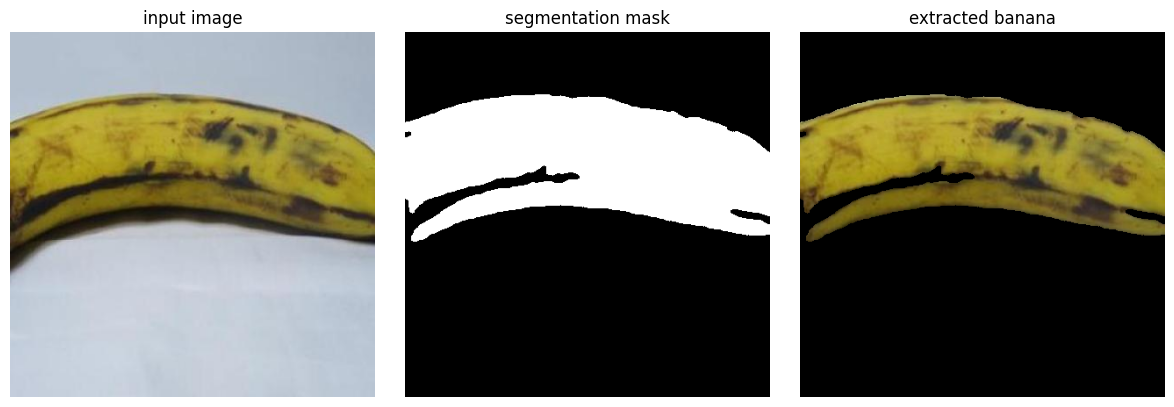

True class      : overripe
Predicted class : OVERRIPE
SVC margins     : {np.str_('overripe'): 3.28, np.str_('ripe'): 2.27, np.str_('rotten'): 0.79, np.str_('unripe'): -0.29}
Reliability     : within validated range (novelty distance 0.264)


In [15]:
from sklearn.neighbors import NearestNeighbors

_scaler = final_model.named_steps["scaler"]
_nn = NearestNeighbors(n_neighbors=1).fit(_scaler.transform(X_fit[:-N_VALID]))
_vdist = _nn.kneighbors(_scaler.transform(X_fit[-N_VALID:]))[0].ravel()
OOD_P95, OOD_P99 = float(np.percentile(_vdist, 95)), float(np.percentile(_vdist, 99))

def predict_image(path):
    rgb = load_rgb(path)
    feats, seg, _ = extract_all_features(rgb, prototypes)
    if feats is None:
        return {"prediction": None, "note": "segmentation produced an empty mask"}
    x = np.array([[feats[k] for k in FEATURE_NAMES]], np.float64)
    pred = str(final_model.predict(x)[0])
    margins = {c: round(float(v), 2) for c, v in
               zip(final_model.named_steps["svm"].classes_, final_model.decision_function(x)[0])}
    d = float(_nn.kneighbors(_scaler.transform(x))[0].ravel()[0])
    reliability = ("within validated range" if d <= OOD_P95
                   else "near the edge of the validated range" if d <= OOD_P99
                   else "OUTSIDE the validated range (advisory only - prediction not changed)")
    return {"rgb": rgb, "mask": seg.final_mask, "prediction": pred,
            "margins": margins, "foreground_fraction": round(seg.foreground_fraction, 3),
            "novelty_distance": round(d, 3), "reliability": reliability}

if DATASET_AVAILABLE:
    # pick a test image the pipeline classifies correctly, for a clear demonstration
    demo_rec = next((r for r in records if r.subset == "test" and r.class_name == "overripe"
                     and predict_image(r.path)["prediction"] == "overripe"),
                    next(r for r in records if r.subset == "test" and r.class_name == "overripe"))
    out = predict_image(demo_rec.path)
    fig, ax = plt.subplots(1, 3, figsize=(12, 4))
    ax[0].imshow(out["rgb"]);                                   ax[0].set_title("input image");       ax[0].axis("off")
    ax[1].imshow(out["mask"], cmap="gray");                     ax[1].set_title("segmentation mask"); ax[1].axis("off")
    ax[2].imshow(np.where(out["mask"][..., None] > 0, out["rgb"], 0)); ax[2].set_title("extracted banana"); ax[2].axis("off")
    plt.tight_layout(); plt.show()
    print("True class      :", demo_rec.class_name)
    print("Predicted class :", out["prediction"].upper())
    print("SVC margins     :", out["margins"])
    print("Reliability     :", out["reliability"], f"(novelty distance {out['novelty_distance']})")
